# Churn Modeling, Customer Segmentation, and Retention Prioritization

## Objective

This notebook extends the churn analysis from descriptive insights into predictive and decision-oriented analytics.

The goals are to:

- train and compare churn prediction models
- evaluate model performance on unseen data
- rank customers by predicted churn risk
- combine churn risk with customer value to prioritize retention
- segment customers into actionable business groups

## Business Context

Earlier analysis showed that churn is concentrated among specific customer groups, especially customers with short tenure, month-to-month contracts, and higher-value service combinations.

This notebook moves from understanding churn patterns to answering a more practical question:

**Which customers should the business prioritize for retention?**

In [1]:
import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
from src.data_loader import load_csv
from src.config import CHURN_CLEAN_FILE
from src.preprocess import prepare_model_data
from src.model import train_logistic, train_random_forest
from src.evaluate import evaluate_model
from sklearn.model_selection import train_test_split


## Load Clean Data

The analysis uses the cleaned churn dataset prepared in `01_notebook_cleandata.ipynb`.

At this stage, the dataset is ready for modeling, but categorical variables still need to be transformed into numeric features before training machine learning models.

In [2]:
df = load_csv(CHURN_CLEAN_FILE)


## Prepare Data for Modeling

To make the dataset suitable for machine learning:

- the target variable `Churn` is separated from the input features
- categorical variables are one-hot encoded
- the resulting feature matrix is used for model training and evaluation

In [3]:
X, y = prepare_model_data(df)


## Train/Test Split

The dataset is split into training and test sets so model performance can be evaluated on unseen data.

A stratified split is used to preserve the churn distribution in both sets.

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train Baseline Models

Two models are trained and compared:

- **Logistic Regression** as an interpretable baseline
- **Random Forest** as a more flexible non-linear model

The goal is to identify a model that performs well while remaining useful in a business setting.

In [5]:

log_model = train_logistic(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)



## Evaluate Model Performance

Model performance is assessed using:

- **ROC-AUC** to measure ranking quality
- **precision** to measure how many predicted churners actually churned
- **recall** to measure how many actual churners were identified
- **confusion matrix** to summarize prediction outcomes

For retention use cases, recall is especially important because missing likely churners reduces intervention effectiveness.

In [6]:
log_results = evaluate_model(log_model, X_test, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)

log_results, rf_results

({'roc_auc': np.float64(0.8362500064709506),
  'report': '              precision    recall  f1-score   support\n\n           0       0.85      0.89      0.87      1033\n           1       0.65      0.57      0.61       374\n\n    accuracy                           0.80      1407\n   macro avg       0.75      0.73      0.74      1407\nweighted avg       0.80      0.80      0.80      1407\n',
  'confusion_matrix': array([[917, 116],
         [159, 215]])},
 {'roc_auc': np.float64(0.8216696605598148),
  'report': '              precision    recall  f1-score   support\n\n           0       0.83      0.90      0.86      1033\n           1       0.64      0.50      0.56       374\n\n    accuracy                           0.79      1407\n   macro avg       0.74      0.70      0.71      1407\nweighted avg       0.78      0.79      0.78      1407\n',
  'confusion_matrix': array([[929, 104],
         [187, 187]])})

## Model Comparison Summary

Logistic Regression achieved the stronger overall performance on the test set and was selected as the primary model for churn scoring.

It provided:

- the better ROC-AUC
- stronger churn recall
- easier interpretation for business use

For this project, Logistic Regression offers the best balance between predictive performance and explainability.

## Score Customers by Predicted Churn Risk

Predicted churn probabilities are generated for customers in the test set.

These probabilities are then used to rank customers from highest to lowest risk, creating a practical base for retention targeting.

In [7]:
test_probs = log_model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df["actual_churn"] = y_test.values
results_df["churn_probability"] = test_probs

results_df = results_df.sort_values(
    "churn_probability",
    ascending=False
)

## Measure Targeting Efficiency

A useful business test is to ask:

**If the business can only target a limited share of customers, how many churners can be captured within that group?**

To answer this, customers are ranked by predicted churn probability and the top 20% highest-risk customers are evaluated.

In [8]:
top_n = int(len(results_df) * 0.2)
top_segment = results_df.head(top_n)

capture_rate = (
    top_segment["actual_churn"].sum()
    / results_df["actual_churn"].sum()
)

print(f"Top 20% capture rate: {capture_rate:.2%}")

Top 20% capture rate: 50.00%


## Top 20% Capture Result

The model captures **50% of all churners within the top 20% highest-risk customers**.

This shows that churn risk is meaningfully concentrated by the model, making targeted retention substantially more efficient than untargeted outreach.

The purpose of the model is not to identify every churner. Its main value is in helping the business focus retention resources where they are most likely to matter.

## Add a Retention Priority Score

Churn probability alone is not enough for decision-making.

A high-risk customer is not always the most important customer to retain. To make prioritization more business-relevant, predicted churn risk is combined with `MonthlyCharges` as a simple proxy for customer value.

This creates a retention priority score that highlights customers who are both:

- likely to churn
- financially important

In [9]:
results_df["MonthlyCharges"] = df.loc[results_df.index, "MonthlyCharges"]

results_df["retention_priority"] = (
    results_df["churn_probability"] * results_df["MonthlyCharges"]
)

results_df = results_df.sort_values(
    "retention_priority",
    ascending=False
)

## Segment Customers by Risk and Value

Customers are grouped using two dimensions:

- predicted churn risk: **Low**, **Medium**, or **High**
- customer value: **Low**, **Medium**, or **High**

This makes the model output easier to translate into business action.

In [10]:
results_df["risk_segment"] = pd.cut(
    results_df["churn_probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

results_df["value_segment"] = pd.qcut(
    results_df["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [11]:
results_df["segment"] = (
    results_df["risk_segment"].astype(str)
    + " / "
    + results_df["value_segment"].astype(str)
)

## Estimate Business Impact

To translate the retention prioritization into business value, the highest-priority customers are treated as a target group for intervention.

A simple scenario is used to estimate impact:

- target the top 500 customers by retention priority
- assume a 25% retention success rate
- use `MonthlyCharges` as a proxy for monthly customer value

This produces an approximate estimate of annual revenue preserved through targeted retention efforts. The result is illustrative rather than a precise financial forecast.

In [12]:
top_targets = results_df.head(500)

avg_value = top_targets["MonthlyCharges"].mean()

saved_customers = 0.25 * len(top_targets)

annual_value = saved_customers * avg_value * 12

print(f"Estimated annual value preserved: ${annual_value:,.0f}")

Estimated annual value preserved: $126,887


## Summarize Segment Performance

Each segment is summarized using:

- number of customers
- observed churn rate
- average monthly value

This helps identify where churn is most severe, where revenue risk is highest, and which segments should be prioritized.

In [13]:
segment_summary = (
    results_df.groupby("segment")
    .agg(
        customers=("segment", "count"),
        churn_rate=("actual_churn", "mean"),
        avg_value=("MonthlyCharges", "mean")
    )
    .sort_values("customers", ascending=False)
)

segment_summary

,customers,churn_rate,avg_value
segment,,,
Low / Low,385,0.085714,25.166364
Low / Medium,240,0.129167,65.218542
Low / High,229,0.117904,98.556550
Medium / High,139,0.410072,96.504317
Medium / Medium,129,0.449612,68.181008
High / High,101,0.643564,92.491089
High / Medium,99,0.696970,74.407071
Medium / Low,73,0.328767,38.631507
High / Low,12,0.833333,32.620833


## Segment Insights

The segment summary shows that churn is heavily concentrated in the high-risk groups.

Key findings include:

- **High Risk / High Value** customers are the most important retention segment because they combine high churn with high revenue at risk
- **High Risk / Medium Value** customers also show very high churn and are strong candidates for targeted, lower-cost interventions
- **Low Risk** segments are comparatively stable and require minimal retention effort
- although **High Risk / Low Value** shows the highest churn rate, it is a small and lower-value segment and should not automatically be the top business priority

This confirms that churn risk alone is not enough. Customer value must also be considered when deciding where to intervene.

## Visualize Churn by Segment

The chart below shows churn rate across customer segments.

It highlights how strongly churn is concentrated in high-risk groups and supports a targeted retention strategy rather than broad untargeted campaigns.

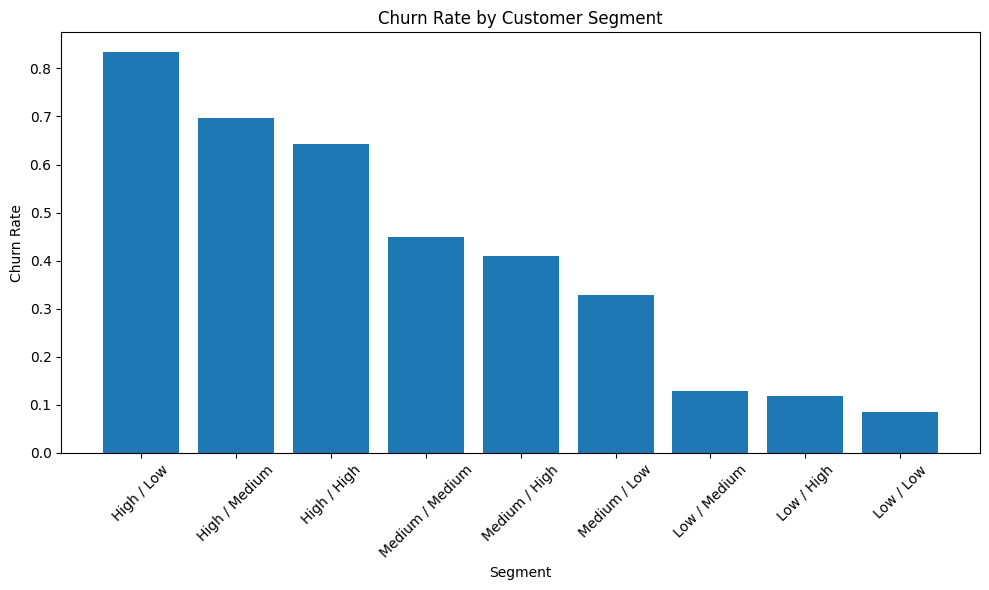

In [14]:
segment_summary_sorted = segment_summary.sort_values("churn_rate", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(segment_summary_sorted.index, segment_summary_sorted["churn_rate"])
plt.xticks(rotation=45)
plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Segment")
plt.tight_layout()
plt.show()

## Interpretation of Segment Chart

The segment chart shows a clear progression from low-risk to high-risk customers.

The most important conclusion is that the business should prioritize **High Risk / High Value** customers rather than simply targeting the segment with the single highest churn rate.

The best retention strategy balances:

- likelihood of churn
- customer value
- expected return from intervention

## Business Conclusion

This modeling workflow translates churn prediction into a practical retention strategy.

The final output is not just a model score, but a prioritization framework that helps answer:

- which customers are most likely to churn
- which of those customers are most valuable
- which segments should receive proactive retention efforts

The strongest retention opportunity is concentrated among high-risk customers with medium-to-high value, where churn rates exceed 60%.

## Limitations and Next Steps

This analysis uses `MonthlyCharges` as a simple proxy for customer value. In a production setting, prioritization could be improved by incorporating:

- customer lifetime value
- retention cost
- campaign response rates
- profit-based targeting thresholds

Future enhancements could also include model explainability methods, such as coefficient interpretation or SHAP analysis, to better understand individual churn drivers.